In [120]:
import math
import torch
import gpytorch
from matplotlib import pyplot as plt

%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [143]:
import os
os.chdir("/lscratch/fgmaion/MTNG-resims/src")
import utils

### Get the data

In [ ]:
# catalog name
catalog = '/scratch/fgmaion/CAMELS/1P/1P_0/groups_090.hdf5'

# value of the scale factor
scale_factor = 1.0

# open the catalogue
f = h5py.File(catalog, 'r')

f['Parameters'].attrs['WindEnergyIn1e51erg']
f['Parameters'].attrs['VariableWindVelFactor']
f['Parameters'].attrs['RadioFeedbackFactor']
f['Parameters'].attrs['RadioFeedbackReiorientationFactor']

# close file
f.close()

In [144]:
smf = {}
index = ['n2', 'n1', '0', '1', '2']

smf['gal_wind'] = {}
smf['rad_fb'] = {}
smf['wind_vel'] = {}
smf['reor_fac'] = {}
for i in range(5):
    smf['gal_wind'][index[i]] = utils.camels_stellar_mf('1P', id_name=index[i], par=3, nbins=20)
    smf['rad_fb'][index[i]] = utils.camels_stellar_mf('1P', id_name=index[i], par=4, nbins=20)
    smf['wind_vel'][index[i]] = utils.camels_stellar_mf('1P', id_name=index[i], par=5, nbins=20)
    smf['reor_fac'][index[i]] = utils.camels_stellar_mf('1P', id_name=index[i], par=6, nbins=20)

/lscratch/fgmaion/MTNG-resims/src/utils.py:589: RuntimeWarning: invalid value encountered in divide
  return  {'smf':norm * counts, 'bins':bins, 'mstar':mstar_mean / counts}


In [195]:
mstar1 = np.log10(smf['gal_wind']['n2']['mstar'][:-5])
mstar2 = np.log10(smf['gal_wind']['n1']['mstar'][:-5])

smf_full  = np.concatenate((np.log10(smf['gal_wind']['n2']['smf'][:-5]), np.log10(smf['gal_wind']['n1']['smf'][:-5])))

In [135]:
#Training data is 100 points in [0,1] inclusive regularly spaced
#train_x = torch.vstack([torch.linspace(0, 1, 100),torch.linspace(0, 1, 100)]).T
#True function is sin(2*pi*x) with Gaussian noise
#train_y = torch.sin(train_x[:,0] * (2 * math.pi)) + torch.randn(train_x[:,0].size()) * math.sqrt(0.04)

In [ ]:
train_x = torch.asarray([ 0.9,  1.8,  3.6,  7.2, 14.4], dtype=torch.float)

In [196]:
train_x = torch.asarray(np.concatenate((list(zip(mstar1, np.ones(len(mstar1)) * 0.9)), list(zip(mstar2, np.ones(len(mstar2)) * 1.8)))), dtype=torch.float)
train_y = torch.asarray(smf_full, dtype=torch.float)

### Build the GP Model

In [197]:
# We will use the simplest form of GP model, exact inference
class ExactGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super(ExactGPModel, self).__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

# initialize likelihood and model
likelihood = gpytorch.likelihoods.GaussianLikelihood()
model = ExactGPModel(train_x, train_y, likelihood)

#### Train it

In [198]:
# this is for running the notebook in our testing framework
import os
smoke_test = ('CI' in os.environ)
training_iter = 2 if smoke_test else 100


# Find optimal model hyperparameters
model.train()
likelihood.train()

# Use the adam optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)  # Includes GaussianLikelihood parameters

# "Loss" for GPs - the marginal log likelihood
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

for i in range(training_iter):
    # Zero gradients from previous iteration
    optimizer.zero_grad()
    # Output from model
    output = model(train_x)
    # Calc loss and backprop gradients
    loss = -torch.sum(mll(output, train_y))
    loss.backward()
    print('Iter %d/%d - Loss: %.3f   lengthscale: %.3f   noise: %.3f' % (
        i + 1, training_iter, loss.item(),
        model.covar_module.base_kernel.lengthscale.item(),
        model.likelihood.noise.item()
    ))
    optimizer.step()

Iter 1/100 - Loss: 1.470   lengthscale: 0.693   noise: 0.693
Iter 2/100 - Loss: 1.355   lengthscale: 0.744   noise: 0.644
Iter 3/100 - Loss: 1.256   lengthscale: 0.798   noise: 0.598
Iter 4/100 - Loss: 1.169   lengthscale: 0.852   noise: 0.554
Iter 5/100 - Loss: 1.093   lengthscale: 0.908   noise: 0.513
Iter 6/100 - Loss: 1.025   lengthscale: 0.964   noise: 0.473
Iter 7/100 - Loss: 0.963   lengthscale: 1.021   noise: 0.436
Iter 8/100 - Loss: 0.907   lengthscale: 1.078   noise: 0.402
Iter 9/100 - Loss: 0.854   lengthscale: 1.134   noise: 0.369
Iter 10/100 - Loss: 0.804   lengthscale: 1.190   noise: 0.339
Iter 11/100 - Loss: 0.757   lengthscale: 1.245   noise: 0.310
Iter 12/100 - Loss: 0.712   lengthscale: 1.300   noise: 0.284
Iter 13/100 - Loss: 0.668   lengthscale: 1.353   noise: 0.259
Iter 14/100 - Loss: 0.625   lengthscale: 1.405   noise: 0.237
Iter 15/100 - Loss: 0.584   lengthscale: 1.455   noise: 0.216
Iter 16/100 - Loss: 0.543   lengthscale: 1.504   noise: 0.196
Iter 17/100 - Los

In [205]:
mstar_test = np.linspace(8,11.5,100)
test_x1 = torch.asarray( list(zip(mstar_test, np.ones(len(mstar_test)) * 0.9)), dtype=torch.float )
test_x2 = torch.asarray( list(zip(mstar_test, np.ones(len(mstar_test)) * 1.8)), dtype=torch.float )

In [206]:
# Get into evaluation (predictive posterior) mode
model.eval()
likelihood.eval()

# Test points are regularly spaced along [0,1]
# Make predictions by feeding model through likelihood
with torch.no_grad(), gpytorch.settings.fast_pred_var():
    observed_pred1 = likelihood(model(test_x1))
    observed_pred2 = likelihood(model(test_x2))

Text(0, 0.5, 'SMF')

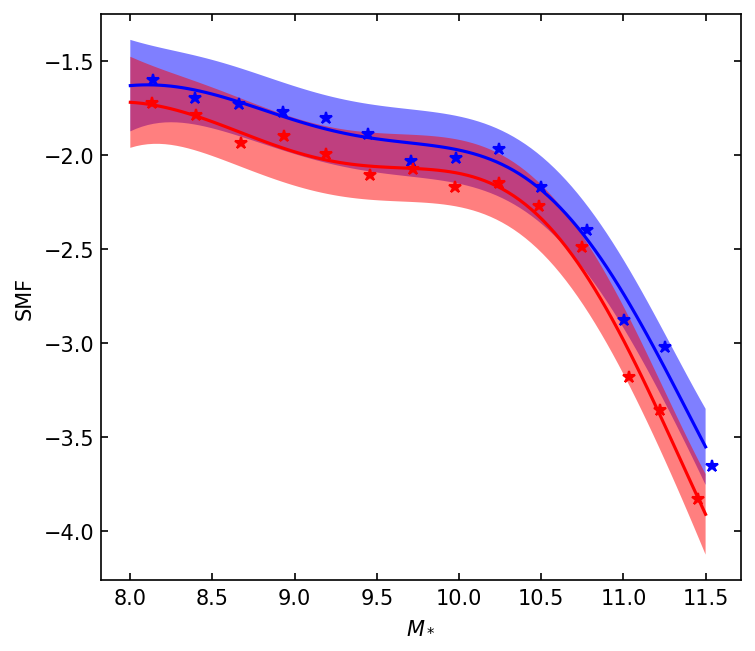

In [213]:
with torch.no_grad():
    # Initialize plot
    f, ax = plt.subplots(1, 1, figsize=(5.5, 5), dpi=150)

    # Get upper and lower confidence bounds
    lower1, upper1 = observed_pred1.confidence_region()
    lower2, upper2 = observed_pred2.confidence_region()
    # Plot training data as black stars
    ax.plot(train_x.numpy()[:len(mstar1),0], train_y.numpy()[:len(mstar1)], 'b*')
    ax.plot(train_x.numpy()[len(mstar1):,0], train_y.numpy()[len(mstar1):], 'r*')
    # Plot predictive means as blue line
    ax.plot(test_x1.numpy()[:,0], observed_pred1.mean.numpy(), 'b')
    ax.plot(test_x2.numpy()[:,0], observed_pred2.mean.numpy(), 'r')
    # Shade between the lower and upper confidence bounds
    ax.fill_between(test_x1.numpy()[:,0], lower1.numpy(), upper1.numpy(), alpha=0.5, color='b', edgecolor=None)
    ax.fill_between(test_x2.numpy()[:,0], lower2.numpy(), upper2.numpy(), alpha=0.5, color='r', edgecolor=None)

ax.set_xlabel('$M_*$')
ax.set_ylabel('SMF')
